# Embedding-Space Structure

This notebook explores image-embedding structure to test:
- Cluster density and near-duplicate semantics
- Hard-to-separate images
- Whether evaluation labels are too strict for the dataset

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EMB_PATH = Path("../data/embeddings/image_embeddings.npz")
IMG_DIR = Path("../data/images")

if not EMB_PATH.exists():
    raise FileNotFoundError(f"Missing embeddings file: {EMB_PATH.resolve()}")

data = np.load(EMB_PATH, allow_pickle=True)

ids = data["ids"]
filenames = data["filenames"]
embeddings = data["embeddings"].astype(np.float32)

print(f"Loaded embeddings: {embeddings.shape}")
print(f"Images dir exists: {IMG_DIR.exists()}")

Loaded embeddings: (39, 512)
Images dir exists: True


In [2]:
# Normalize embeddings for cosine similarity
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
emb = embeddings / np.clip(norms, 1e-8, None)

## 2D Projections (PCA, t-SNE, UMAP)

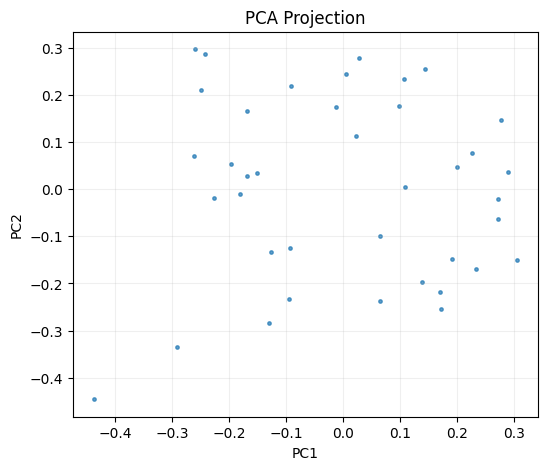

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(emb)

plt.figure(figsize=(6, 5))
plt.scatter(emb_pca[:, 0], emb_pca[:, 1], s=6, alpha=0.7)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.show()

t-SNE points: 39 / 39


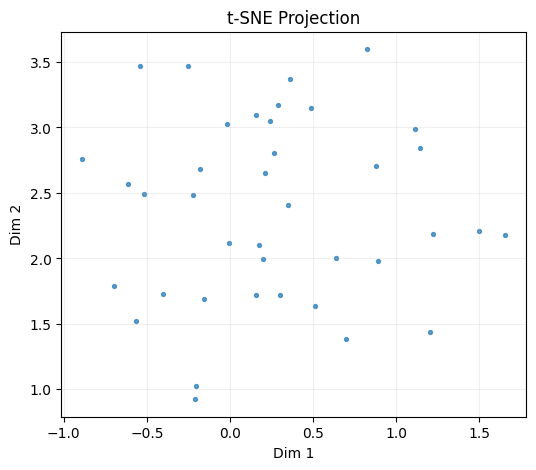

In [4]:
# t-SNE can be slow on large datasets. Sample if needed.
from sklearn.manifold import TSNE

n = emb.shape[0]
max_points = 2000

if n > max_points:
    rng = np.random.default_rng(42)
    idx = rng.choice(n, size=max_points, replace=False)
    emb_tsne = emb[idx]
else:
    idx = np.arange(n)
    emb_tsne = emb

print(f"t-SNE points: {len(idx)} / {n}")

tsne = TSNE(n_components=2, perplexity=30, init="random", random_state=42, learning_rate="auto")
emb_tsne_2d = tsne.fit_transform(emb_tsne)

plt.figure(figsize=(6, 5))
plt.scatter(emb_tsne_2d[:, 0], emb_tsne_2d[:, 1], s=8, alpha=0.7)
plt.title("t-SNE Projection")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(alpha=0.2)
plt.show()

## Intra-dataset Similarity Distribution

Sampled 723 pairwise similarities
Mean: 0.5246, Std: 0.0847
95th pct: 0.6735
99th pct: 0.7274


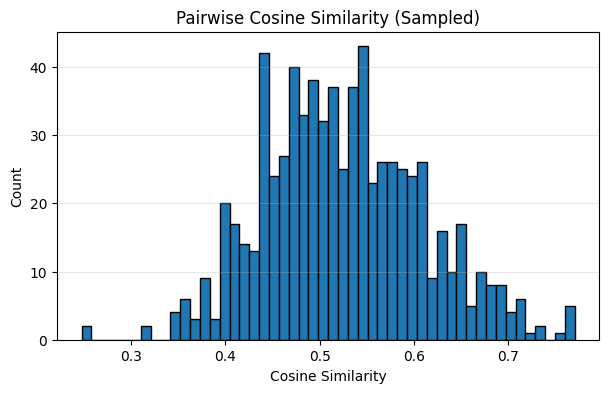

In [6]:
# Sample pairwise cosine similarities for scalability
rng = np.random.default_rng(42)

n = emb.shape[0]
num_pairs = min(200000, n * (n - 1) // 2)

# Sample random pairs (i, j)
idx_i = rng.integers(0, n, size=num_pairs)
idx_j = rng.integers(0, n, size=num_pairs)
mask = idx_i != idx_j
idx_i = idx_i[mask]
idx_j = idx_j[mask]

sims = np.sum(emb[idx_i] * emb[idx_j], axis=1)

print(f"Sampled {len(sims)} pairwise similarities")
print(f"Mean: {sims.mean():.4f}, Std: {sims.std():.4f}")
print(f"95th pct: {np.percentile(sims, 95):.4f}")
print(f"99th pct: {np.percentile(sims, 99):.4f}")

plt.figure(figsize=(7, 4))
plt.hist(sims, bins=50, edgecolor="black")
plt.title("Pairwise Cosine Similarity (Sampled)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()